## 이벤트별 집계 확인

이 코드는 사용자의 서비스 전환 과정을 파악하기 위해, 퍼널(Funnel) 분석 대상이 될 핵심 이벤트를 선별하고 집계하는 단계임. **AARRR 프레임워크의 Activation(활성화) 단계**에서 사용자가 핵심 가치를 경험하는 지점을 파악하는 데 활용됨.

* **`event_name` 기준 집계:** 서비스 내 발생하는 전체 이벤트 종류 및 발생 건수 확인
* **사용자 수(`unique_users`) 함께 확인:** 단순히 총 발생 수만 보는 것이 아니라, 실제 해당 행동을 경험한 사용자 기반의 규모 측정

### 주요 확인 포인트
* **이벤트 라인업 파악:** Activation 퍼널을 구성할 핵심 행동(이벤트)이 정상적으로 수집되고 있는지 확인
* **Activation 퍼널 이벤트 선별:** 가입 이후 첫 핵심 기능 이용, 주요 페이지 방문 등 퍼널 단계별 기준이 될 이벤트를 결정


In [14]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    COUNT(*) AS event_count,
    COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name
ORDER BY event_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

             event_name  event_count  unique_users
0             page_view      1350428        269792
1       user_engagement      1058721        213004
2                scroll       493072        138098
3             view_item       386068         61252
4         session_start       354970        267116
5           first_visit       257462        257314
6        view_promotion       190104        102443
7           add_to_cart        58543         12545
8        begin_checkout        38757          9715
9           select_item        31007         13180
10  view_search_results        26172         14449
11    add_shipping_info        19722          9714
12     add_payment_info        13899          5751
13     select_promotion         9450          8164
14             purchase         5692          4419
15                click         1446          1010
16       view_item_list           71            44


# GA4 주요 이벤트 정의
Google Analytics 4(GA4)에서 수집되는 주요 이벤트를 공식 이벤트 정의 기준으로 정리한 문서입니다.

| 구분 | 이벤트 | 정의 및 발생 조건 | 분석 시 주요 의미 |
|:---:|:---|:---|:---|
| 자동 수집 | `page_view` | 페이지가 로드되거나, 활성 사이트에서 브라우저 기록 상태가 변경될 때 발생합니다. | 페이지 조회 및 화면 전환량 측정 |
| 자동 수집 | `scroll` | 사용자가 각 페이지에서 처음으로 하단에 도달했을 때 발생합니다. 웹에서는 세로 기준으로 페이지의 90% 이상이 표시된 경우를 의미합니다. | 콘텐츠 도달 및 페이지 참여도 측정 |
| 자동 수집 | `session_start` | 사용자가 앱 또는 웹사이트에 참여할 때 발생합니다. 세션 ID와 세션 번호는 세션마다 자동으로 생성되며 세션의 각 이벤트에 연결됩니다. | 세션 수와 방문 시작 시점 파악 |
| 자동 수집 | `user_engagement` | 앱이 포그라운드에 있거나 웹페이지가 최소 1초간 포커스 상태일 때 발생합니다. | 실제 사용자 참여 시간 및 활성도 측정 |
| 자동 수집 | `view_search_results` | URL에 검색어 쿼리 매개변수가 포함되어 사용자가 사이트 검색을 수행한 것으로 간주될 때마다 발생합니다. | 사이트 검색 이용 현황 및 검색어 분석 |
| 자동 수집 | `first_visit` | 사용자가 웹사이트를 처음 방문하거나, 애널리틱스를 사용하는 Android 인스턴트 앱을 처음 실행할 때 발생합니다. | 신규 사용자 유입 및 최초 방문 분석 |
| 전자상거래 | `add_payment_info` | 사용자가 결제 과정에서 결제 정보를 제출할 때 발생합니다. | 결제 정보 입력 단계의 진행 및 이탈 분석 |
| 전자상거래 | `add_shipping_info` | 사용자가 결제 과정에서 배송 정보를 제출할 때 발생합니다. | 배송 정보 입력 단계의 진행 및 이탈 분석 |
| 전자상거래 | `add_to_cart` | 사용자가 상품을 장바구니에 추가할 때 발생합니다. | 상품 관심도 및 장바구니 전환 분석 |
| 전자상거래 | `begin_checkout` | 사용자가 결제 프로세스를 시작할 때 발생합니다. | 장바구니에서 결제로 이동한 사용자 분석 |
| 전자상거래 | `purchase` | 사용자가 구매를 완료할 때 발생합니다. | 매출, 구매 건수 및 구매 전환 분석 |
| 전자상거래 | `view_item` | 사용자가 상품을 조회할 때 발생합니다. | 개별 상품 조회 및 상품 관심도 분석 |
| 전자상거래 | `view_item_list` | 사용자가 상품 또는 서비스 목록을 조회할 때 발생합니다. | 목록 노출 및 상품 탐색 분석 |
| 프로모션 | `view_promotion` | 사용자가 웹사이트 또는 앱에서 프로모션을 조회할 때 발생합니다. | 프로모션 노출 및 도달 분석 |
| 프로모션 | `select_promotion` | 사용자가 프로모션을 선택할 때 발생합니다. | 프로모션 클릭 및 프로모션 유입 분석 |
| 상품 목록 상호작용 | `select_item` | 사용자가 상품 또는 서비스 목록에서 항목을 선택할 때 발생합니다. | 목록에서 개별 상품으로 이동한 행동 분석 |
| 사용자 상호작용 | `click` | 사용자가 현재 도메인에서 나가는 링크를 클릭할 때마다 발생합니다. | 외부 링크 클릭 및 이탈 경로 분석 |

---

# Activation 퍼널 분석 계획

> **목표:** 상품을 조회한 사용자가 구매까지 이어지는 과정을 단계별로 추적하고, 각 단계의 이탈 지점을 파악한다.

## 1. 핵심 질문

**상품을 조회한 사용자 중 몇 명이 구매까지 도달하며, 가장 큰 이탈은 어느 단계에서 발생하는가?**

본 분석의 최종 목적지는 구매 완료이며, 퍼널 각 단계의 도달률과 이탈 규모를 산출한다. 방문 자체보다 상품에 관심을 보인 시점부터 여정을 추적하기 위해 `view_item`을 퍼널 시작점으로 둔다.

활성화 기준 이벤트(어느 단계 도달을 '활성화'로 정의할 것인가)는 본 퍼널 결과와 후속 리텐션·LTV 검증을 통해 확정한다.

## 2. 분석 퍼널

| 순서 | 사용자 행동 | 이벤트 |
|:---:|:---|:---|
| 1 | 상품 조회 | `view_item` |
| 2 | 장바구니 담기 | `add_to_cart` |
| 3 | 결제 시작 | `begin_checkout` |
| 4 | 배송정보 입력 | `add_shipping_info` |
| 5 | 결제정보 입력 | `add_payment_info` |
| 6 | 구매 완료 | `purchase` |

### 시작점을 `view_item`으로 정한 이유

- 본 분석은 방문 이후 상품에 관심을 보인 사용자가 구매까지 이어지는지에 초점을 둔다.
- `view_item_list`는 분석 기간 내 발생 건수가 71건에 불과해 퍼널 단계로서 유의미하지 않아 제외한다.
- `select_item`은 광고나 공유 링크를 통한 유입 시 목록 조회 없이 `view_item`으로 직행할 수 있어 필수 경로가 아니므로 제외한다. (※ 실제 발생 건수 확인 후 수치 근거 보완)

## 3. 분석 설계

### 3-1. 분석 기간

**2020-11-02(월) ~ 2021-01-31(일), 91일 = 13주**

데이터셋 보유 기간은 2020-11-01부터이나, 사용자 유치 분석의 주 단위 집계와 모집단을 일치시키기 위해 일요일인 2020-11-01을 제외한다. 그 결과 분석 기간은 월요일 시작, 일요일 종료의 완전한 13주로 구성된다.

### 3-2. 집계 단위와 모집단

| 구분 | 정의 |
|:---|:---|
| 집계 단위 | `user_pseudo_id` (고유 사용자 1명 = 1) |
| 모집단 | 분석 기간 내 `first_visit` 이벤트 보유자 (신규 사용자) |
| 퍼널 1단계 | 모집단 중 `view_item` 도달자 |

`user_id`는 해당 데이터셋에 수집되어 있지 않아(전 구간 0건) 로그인 기반 개인 식별이 불가능하다. 모집단을 신규 사용자로 한정하는 것은 기존 재방문 고객이 섞여 전환율이 과대 추정되는 것을 방지하기 위함이다.

### 3-3. 단계 도달 판정 규칙

각 단계는 **직전에 도달한 단계 이후에 발생해야** 도달로 인정한다(시간순 검증). 단, 선행 단계를 모두 완료할 것은 요구하지 않으며 단계 건너뛰기를 허용한다.

- 기준 시점은 "직전 순번 단계"가 아니라 "실제로 도달한 마지막 단계"로 하며, 도달한 이전 단계가 없으면 퍼널 진입 시점을 기준으로 한다.
- GA4는 이벤트를 배치로 전송하므로 서로 다른 이벤트가 동일한 `event_timestamp`를 가질 수 있다. 따라서 선후 판정은 역행만 배제하는 방식(`>=`)을 적용한다.
- 동일 사용자가 같은 이벤트를 여러 번 발생시켜도 1명으로 집계한다.
- 세션을 구분하지 않고 사용자 단위로 집계한다.

### 3-4. 전환율 산출

| 지표 | 계산식 |
|:---|:---|
| 퍼널 진입률 | `view_item` 도달자 ÷ 신규 사용자 |
| 순차 전환율 | 해당 단계 도달자 ÷ 직전 단계 도달자 |
| 누적 전환율 | 해당 단계 도달자 ÷ `view_item` 도달자 |

순차 전환율로 병목 구간을, 누적 전환율로 전체 손실 규모를 파악한다.

## 4. 분석의 한계

1. **기기 단위 식별** — `user_pseudo_id`는 쿠키·브라우저 기반 식별자다. 다기기 사용자는 복수 사용자로 분리 집계되므로, 순 사용자 수는 **과대**, 전환율은 **과소** 추정되는 방향으로 편향된다.

2. **선행 단계 완료 미요구** — 시간 순서는 검증하지만 선행 단계를 모두 완료했을 것은 요구하지 않는다. 따라서 특정 단계 도달자 중에는 이전 단계 이벤트가 기록되지 않은 사용자가 포함될 수 있으며, 하위 단계 인원이 상위 단계를 초과하는 역전 현상이 발생할 수 있다. 이는 계측 누락과 정상적인 단계 생략(저장된 결제수단 사용 등)을 배제하지 않기 위한 설계상 선택이며, 해당 사례는 별도 품질 지표로 보고한다.

3. **상품 단위 미매칭** — 조회한 상품과 구매한 상품의 동일성을 확인하지 않는다. 따라서 본 지표는 상품별 전환이 아니라 사용자의 단계 도달 여부를 측정한다.

4. **인과관계 미보장** — 세션을 구분하지 않고 사용자 단위로 집계하므로 수일 간격으로 떨어진 이벤트도 하나의 지표에 함께 반영된다. 그러나 이들이 연속된 의사결정의 결과라는 근거는 없으며, 그 사이에 개입한 외부 요인(광고 노출, 외부 추천 등)은 관측되지 않는다. 짧은 윈도우를 설정할수록 이 비약은 줄어든다.

5. **관측 기간 불균등** — 현 단계에서는 관측 윈도우를 적용하지 않으므로 초기 유입자가 후기 유입자보다 긴 관찰 기간을 갖는다. 결과적으로 전환율은 초기 코호트에 유리하게 산출된다. 전체 기간 결과 확인 후 첫 방문→구매 소요 시간 분포를 근거로 윈도우를 설정하여 해소한다.

---

## 관측 기간 사용자 구성 확인 (신규 / 신규 외)

분석 기간(2020-11-02 ~ 2021-01-31) 내 활동한 사용자를 `first_visit` 보유 여부로 나눠, 퍼널 모집단인 신규 사용자가 전체의 몇 %를 차지하는지 확인하는 단계임.

* **전체 사용자:** 기간 내 이벤트를 1건이라도 발생시킨 고유 `user_pseudo_id` 수
* **신규 사용자:** 그중 `first_visit` 이벤트를 보유한 사용자
* **신규 외 사용자:** 전체 − 신규

### 해석 시 주의
* 데이터셋 수집 시작일이 2020-11-01이라 그 이전 방문 이력은 관측되지 않음. '신규 외'의 실제 첫 방문 시점은 알 수 없고, 11-01 이전부터 존재했다는 사실만 확인 가능함.
* 집계 단위가 `user_pseudo_id`이므로 `first_visit` 이벤트 중복(고유 사용자 수보다 약 148건 많음)은 결과에 영향을 주지 않음.

In [15]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    COUNT(DISTINCT user_pseudo_id) AS total_users,
    COUNT(DISTINCT IF(event_name = 'first_visit', user_pseudo_id, NULL)) AS new_users,
    COUNT(DISTINCT user_pseudo_id)
        - COUNT(DISTINCT IF(event_name = 'first_visit', user_pseudo_id, NULL)) AS non_new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    AND user_pseudo_id NOT IN (
        SELECT user_pseudo_id
        FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20201101`
        WHERE event_name = 'first_visit'
            AND user_pseudo_id IS NOT NULL
    )
"""

df = client.query(query).to_dataframe()
print(df)

   total_users  new_users  non_new_users
0       267971     255368          12603


## Activation 퍼널 단계별 도달자 집계 — 전체 기간

> 관측 윈도우를 적용하지 않은 **기준선(baseline)** 집계임. 사용자마다 관측 기간이 달라 전환율을 서로 비교할 수 없음

| 컬럼 | 의미 |
|:---|:---|
| `신규대비(%)` | 도달자 ÷ 신규 사용자 (0단계 = 100%, 누적 도달률) |
| `직전대비(%)` | 도달자 ÷ 직전 단계 도달자 (순차 전환율, 병목 식별용) |

### 도달 판정

사용자마다 **마지막으로 도달한 단계의 시각**을 기억해 두고, 그 시각 이후에 발생한 이벤트만 다음 단계 도달로 인정함. 기준 시각의 출발점은 첫 방문(`first_visit`) 시각이며, 같은 시각에 찍힌 이벤트도 인정함(GA4가 이벤트를 묶어 전송해 시각이 겹칠 수 있기 때문).

중간 단계를 건너뛰어도 기준 시각은 그대로 유지되므로 이후 단계 판정은 계속 이루어짐. 예를 들어 장바구니를 거치지 않고 바로 결제를 시작한 사용자는 **상품 조회 시각**을 기준으로 결제 시작 도달 여부를 판정함.

단계별 CTE는 구조가 동일하므로 `FUNNEL` 목록을 순회해 생성함.

### 주의
* 선행 단계 완료를 요구하지 않으므로 `직전대비(%)`가 100%를 넘는 역전 현상이 나타날 수 있음.
* 0단계 수치는 직전 셀의 `new_users`와 일치해야 함.

In [16]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

TBL = "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events"
START, END = "20201102", "20210131"

FUNNEL = [
    ("상품 조회", "view_item"),
    ("장바구니 담기", "add_to_cart"),
    ("결제 시작", "begin_checkout"),
    ("배송정보 입력", "add_shipping_info"),
    ("결제정보 입력", "add_payment_info"),
    ("구매 완료", "purchase"),
]

# 단계별 CTE 생성 (구조가 동일해 루프로 생성)
# cur = 실제로 도달한 마지막 단계의 시점. 미도달 시 COALESCE로 직전 값 유지 → 단계 건너뛰기 허용
stage_sql, prev, carried = [], "new_user", []
for i, (_, event) in enumerate(FUNNEL, start=1):
    hit = f"MIN(IF(e.event_name = '{event}' AND e.event_timestamp >= p.cur, e.event_timestamp, NULL))"
    keep_sel = "".join(f"        p.{c},\n" for c in carried)
    keep_grp = "".join(f", p.{c}" for c in carried)
    stage_sql.append(
        f"""s{i} AS (
    SELECT
        p.user_pseudo_id,
{keep_sel}        COALESCE({hit}, p.cur) AS cur,
        {hit} IS NOT NULL AS r{i}
    FROM {prev} AS p
    LEFT JOIN ev AS e ON p.user_pseudo_id = e.user_pseudo_id
    GROUP BY p.user_pseudo_id, p.cur{keep_grp}
)"""
    )
    carried.append(f"r{i}")
    prev = f"s{i}"

stages_block = ",\n".join(stage_sql)
event_list = ", ".join(f"'{e}'" for _, e in FUNNEL)
count_cols = ",\n    ".join(f"COUNTIF(r{i}) AS r{i}" for i in range(1, len(FUNNEL) + 1))

query = f"""
WITH new_user AS (
    -- 모집단: 분석 기간 내 첫 방문 사용자 (2020-11-01 첫 방문자 제외)
    SELECT user_pseudo_id, MIN(event_timestamp) AS cur
    FROM `{TBL}_*`
    WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
        AND event_name = 'first_visit'
        AND user_pseudo_id NOT IN (
            SELECT user_pseudo_id
            FROM `{TBL}_20201101`
            WHERE event_name = 'first_visit'
                AND user_pseudo_id IS NOT NULL
        )
    GROUP BY user_pseudo_id
),
ev AS (
    -- 모집단 사용자의 퍼널 이벤트만 추림
    SELECT user_pseudo_id, event_name, event_timestamp
    FROM `{TBL}_*`
    WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
        AND event_name IN ({event_list})
        AND user_pseudo_id IN (SELECT user_pseudo_id FROM new_user)
),
{stages_block}
SELECT
    COUNT(*) AS new_users,
    {count_cols}
FROM s{len(FUNNEL)}
"""

row = client.query(query).to_dataframe().iloc[0]

rows = [("0. 신규 사용자", "first_visit", int(row["new_users"]))]
for i, (label, event) in enumerate(FUNNEL, start=1):
    rows.append((f"{i}. {label}", event, int(row[f"r{i}"])))

funnel_df = pd.DataFrame(rows, columns=["단계", "이벤트", "사용자수"])
funnel_df["신규대비(%)"] = (funnel_df["사용자수"] / funnel_df.loc[0, "사용자수"] * 100).round(1)
funnel_df["직전대비(%)"] = (funnel_df["사용자수"] / funnel_df["사용자수"].shift(1) * 100).round(1)

print(funnel_df.to_string(index=False))

        단계               이벤트   사용자수  신규대비(%)  직전대비(%)
 0. 신규 사용자       first_visit 255368    100.0      NaN
  1. 상품 조회         view_item  55332     21.7     21.7
2. 장바구니 담기       add_to_cart  11253      4.4     20.3
  3. 결제 시작    begin_checkout   7648      3.0     68.0
4. 배송정보 입력 add_shipping_info   5120      2.0     66.9
5. 결제정보 입력  add_payment_info   4506      1.8     88.0
  6. 구매 완료          purchase   3456      1.4     76.7


## 퍼널 시각화 — 전체 기간

두 지표를 한 그림에 겹치지 않고 같은 행에 정렬해 나란히 배치함.

* **왼쪽(퍼널):** 막대 폭 자체가 누적 전환율임. 신규 사용자 폭을 100%로 두고 각 단계 도달자 비율만큼 좁아짐.
* **오른쪽:** 직전 단계 대비 전환율. 단계가 아니라 **단계 사이의 전이**를 나타내는 값이라 퍼널 도형에 넣지 않고 분리함.

### 읽는 법
* 폭의 급감은 **초반 두 단계에 집중**됨 (신규→조회 21.7%, 조회→장바구니 20.3%).
* 결제 시작 이후는 67~88%로 유지되므로, 병목은 결제 흐름이 아니라 **그 앞단**에 있음.

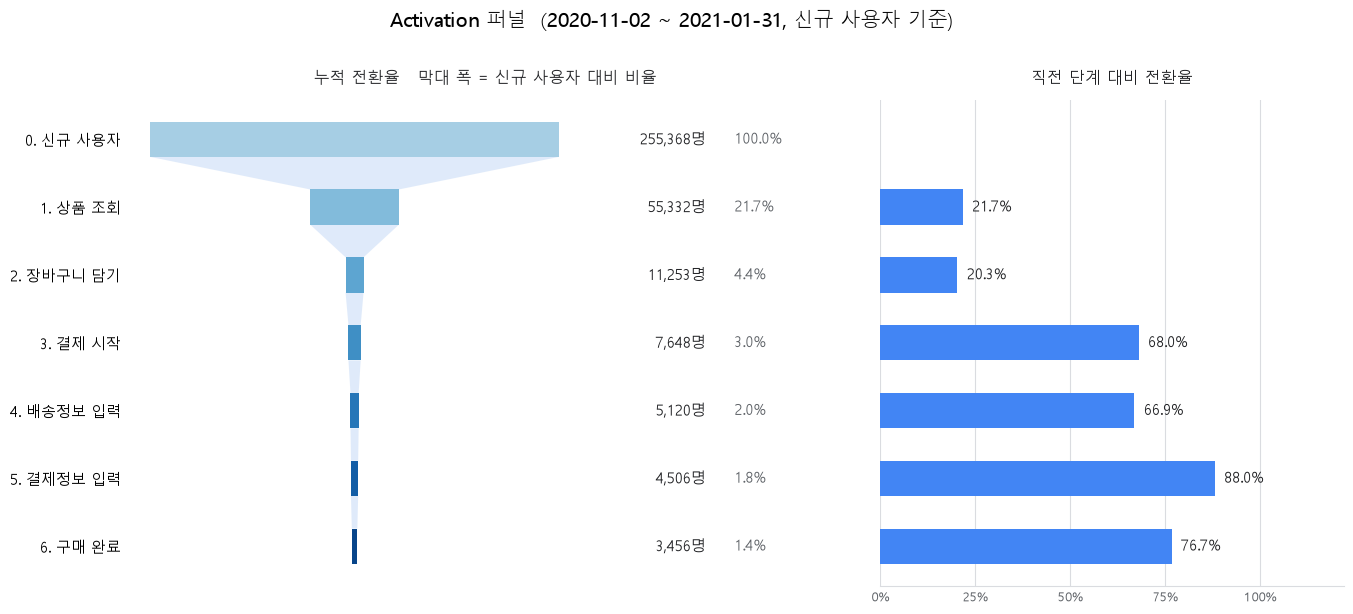

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

labels = funnel_df['단계'].tolist()
users  = funnel_df['사용자수'].to_numpy()
cum    = funnel_df['신규대비(%)'].to_numpy()
step   = funnel_df['직전대비(%)'].to_numpy()
n      = len(labels)

width  = users / users[0]          # 막대 폭 = 누적 전환율
colors = plt.cm.Blues(np.linspace(0.35, 0.92, n))
BAR_H  = 0.52

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.4), sharey=True,
                               gridspec_kw={'width_ratios': [1.55, 1], 'wspace': 0.06})

# 단계 사이 사다리꼴 연결부 → 퍼널 형태
for i in range(n - 1):
    w0, w1 = width[i] / 2, width[i + 1] / 2
    ax1.fill([-w0, w0, w1, -w1],
             [i + BAR_H / 2, i + BAR_H / 2, i + 1 - BAR_H / 2, i + 1 - BAR_H / 2],
             color='#C6DAF6', alpha=0.55, linewidth=0)

ax1.barh(range(n), width, left=-width / 2, height=BAR_H, color=colors)
for i in range(n):
    ax1.text(0.86, i, f'{users[i]:,}명', va='center', ha='right', fontsize=10.5, color='#202124')
    ax1.text(0.93, i, f'{cum[i]:.1f}%',  va='center', ha='left',  fontsize=10.5, color='#5F6368')
ax1.set_xlim(-0.56, 1.20)
ax1.set_xticks([])
ax1.set_yticks(range(n))
ax1.set_yticklabels(labels, fontsize=11)
ax1.invert_yaxis()
ax1.set_title('누적 전환율   막대 폭 = 신규 사용자 대비 비율', fontsize=11.5, pad=12, color='#202124')
for s in ax1.spines.values():
    s.set_visible(False)
ax1.tick_params(length=0)

ax2.barh(range(1, n), step[1:], height=BAR_H, color='#4285F4')
for i in range(1, n):
    ax2.text(step[i] + 2.5, i, f'{step[i]:.1f}%', va='center', ha='left', fontsize=10.5, color='#202124')
ax2.set_xlim(0, 122)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9.5, color='#5F6368')
ax2.set_title('직전 단계 대비 전환율', fontsize=11.5, pad=12, color='#202124')
ax2.xaxis.grid(True, color='#DADCE0', linewidth=0.8)
ax2.set_axisbelow(True)
for s in ('top', 'right', 'left'):
    ax2.spines[s].set_visible(False)
ax2.spines['bottom'].set_color('#DADCE0')
ax2.tick_params(length=0)

fig.suptitle('Activation 퍼널  (2020-11-02 ~ 2021-01-31, 신규 사용자 기준)', fontsize=14.5, y=0.98)
fig.subplots_adjust(top=0.84, bottom=0.08, left=0.11, right=0.98)

plt.savefig('activation_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## 첫 방문 후 경과일별 누적 전환율

1월 말 유입자는 전환할 시간이 부족해 전환율이 과소 추정되므로, 첫 방문 후 며칠까지 봐야 전환이 사실상 끝나는지 확인해 윈도우 길이를 정함.

### 계산

```
days_to_convert  = DATE(첫 purchase) - DATE(first_visit)      # 미구매자는 NULL
N일 누적 전환율  = (days_to_convert <= N 인 사용자) / (N일을 채울 기회가 있었던 사용자)
```

**분모를 N마다 다시 잡는 것이 핵심임.** 전체 신규 사용자를 계속 분모로 쓰면 N일을 채울 시간이 없었던 후기 유입자까지 '미전환'으로 세어 곡선이 아래로 눌림. 따라서 각 N에 대해 `first_visit_date <= 2021-01-31 - N` 인 사용자만 분모에 포함함.

### 읽는 법
* **위:** 곡선이 평탄해지는 지점이 관측 윈도우 후보임. 7 / 14 / 21 / 30 / 45 / 60일 수치를 표시함.
* **아래:** N이 커질수록 분모가 줄어 추정이 불안정해짐. 윈도우는 분모가 충분히 남은 구간에서 골라야 하므로 두 지표를 같은 x축에 배치함.

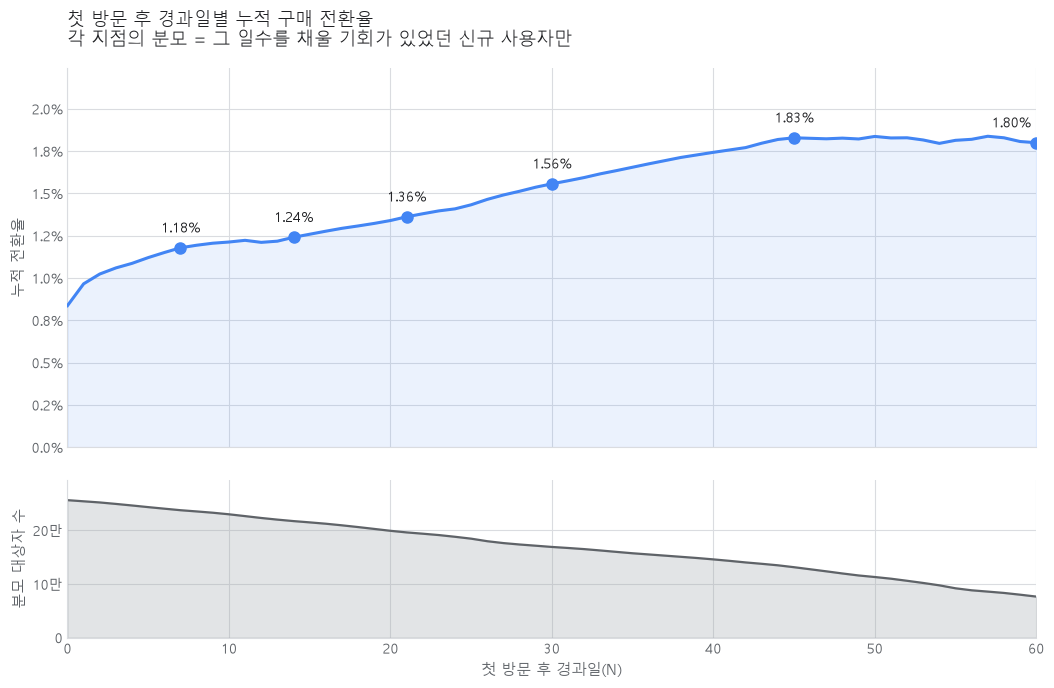

 days  eligible_users  converted_users  cum_rate
    7          236703             2791     1.179
   14          216483             2686     1.241
   21          195475             2662     1.362
   30          168467             2623     1.557
   45          130824             2393     1.829
   60           76274             1373     1.800


In [18]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import numpy as np

client = bigquery.Client(project="pro-talon-503713-s3")

TBL = "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events"
START, END = "20201102", "20210131"
LAST_DAY, MAX_N = "2021-01-31", 60

query = f"""
WITH nov01 AS (
    SELECT DISTINCT user_pseudo_id
    FROM `{TBL}_20201101`
    WHERE event_name = 'first_visit' AND user_pseudo_id IS NOT NULL
),
new_user AS (
    -- 모집단: 앞선 셀들과 동일 (2020-11-01 첫 방문자 제외)
    SELECT
        user_pseudo_id,
        MIN(event_timestamp) AS t0,
        DATE(TIMESTAMP_MICROS(MIN(event_timestamp))) AS first_visit_date
    FROM `{TBL}_*`
    WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
        AND event_name = 'first_visit'
        AND user_pseudo_id NOT IN (SELECT user_pseudo_id FROM nov01)
    GROUP BY user_pseudo_id
),
first_purchase AS (
    SELECT user_pseudo_id, MIN(event_timestamp) AS t_purchase
    FROM `{TBL}_*`
    WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
        AND event_name = 'purchase'
    GROUP BY user_pseudo_id
),
user_level AS (
    -- 1단계: 사용자별 전환 소요일 (미구매자는 NULL)
    SELECT
        n.user_pseudo_id,
        n.first_visit_date,
        DATE_DIFF(DATE(TIMESTAMP_MICROS(p.t_purchase)), n.first_visit_date, DAY) AS days_to_convert
    FROM new_user AS n
    LEFT JOIN first_purchase AS p
        ON n.user_pseudo_id = p.user_pseudo_id
        AND p.t_purchase >= n.t0        -- 첫 방문보다 앞선 구매는 배제
)
-- 2단계: N일 시점 누적 전환율 (분모를 N마다 다시 산정)
SELECT
    n AS days,
    COUNT(*) AS eligible_users,
    COUNTIF(days_to_convert <= n) AS converted_users,
    ROUND(COUNTIF(days_to_convert <= n) / COUNT(*) * 100, 3) AS cum_rate
FROM UNNEST(GENERATE_ARRAY(0, {MAX_N})) AS n
CROSS JOIN user_level
WHERE first_visit_date <= DATE_SUB(DATE '{LAST_DAY}', INTERVAL n DAY)
GROUP BY n
ORDER BY n
"""

df_days = client.query(query).to_dataframe()

d = df_days['days'].to_numpy()
r = df_days['cum_rate'].to_numpy()
e = df_days['eligible_users'].to_numpy()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 7.4), sharex=True,
                               gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.12})

ax1.plot(d, r, color='#4285F4', linewidth=2.2, zorder=3)
ax1.fill_between(d, 0, r, color='#4285F4', alpha=0.10, zorder=1)

for x in [7, 14, 21, 30, 45, 60]:
    y = r[d == x][0]
    off, ha = ((-4, 11), 'right') if x >= d.max() else ((0, 11), 'center')
    ax1.plot(x, y, 'o', color='#4285F4', markersize=8, zorder=4)
    ax1.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=off,
                 ha=ha, fontsize=10, color='#202124')

ax1.set_ylim(0, r.max() * 1.22)
ax1.set_ylabel('누적 전환율', fontsize=11, color='#5F6368')
ax1.yaxis.set_major_formatter(lambda v, p: f'{v:.1f}%')
ax1.set_title('첫 방문 후 경과일별 누적 구매 전환율\n각 지점의 분모 = 그 일수를 채울 기회가 있었던 신규 사용자만',
              fontsize=13, pad=16, loc='left', color='#202124')
ax1.grid(True, color='#DADCE0', linewidth=0.8)
ax1.set_axisbelow(True)

ax2.fill_between(d, 0, e, color='#9AA0A6', alpha=0.28)
ax2.plot(d, e, color='#5F6368', linewidth=1.6)
ax2.set_ylim(0, e.max() * 1.15)
ax2.set_xlim(0, d.max())
ax2.set_ylabel('분모 대상자 수', fontsize=11, color='#5F6368')
ax2.set_xlabel('첫 방문 후 경과일(N)', fontsize=11, color='#5F6368')
ax2.yaxis.set_major_formatter(lambda v, p: f'{v/10000:.0f}만' if v else '0')
ax2.grid(True, color='#DADCE0', linewidth=0.8)
ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#DADCE0')
    ax.tick_params(length=0, colors='#5F6368')

plt.savefig('activation_days_to_convert.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_days[df_days['days'].isin([7, 14, 21, 30, 45, 60])].to_string(index=False))

# 관측 윈도우(Observation Window) 설정 근거

## 1. 왜 필요한가

신규 사용자마다 마감일(2021-01-31)까지 남은 관측 기간이 다르다 — 11/02 유입자는 약 90일, 1/25 유입자는 약 6일. 이 상태로 "마감일까지 구매했는가"만 보면(퍼널의 1.4%), 늦게 유입된 사용자는 **시간이 부족했을 뿐인데 미전환으로 잡혀** 전체 수치가 실제보다 낮아진다. 모든 사용자에게 **동일한 N일의 관측 기회**를 부여해 이 편향을 제거하는 것이 윈도우 설정이다.

## 2. 확인한 데이터

N일을 채울 시간이 있었던 사용자만 분모로 삼아 누적 전환율을 산출했다.

| 경과일(N) | 분석 대상 | 전체 대비 | 누적 전환율 |
|---:|---:|---:|---:|
| 0 | 255,368 | 100.0% | 0.837% |
| 7 | 236,703 | 92.7% | 1.179% |
| 14 | 216,483 | 84.8% | 1.241% |
| 21 | 195,475 | 76.6% | 1.362% |
| **30** | **168,467** | **66.0%** | **1.557%** |
| 45 | 130,824 | 51.2% | 1.829% |
| 60 | 76,274 | 29.9% | 1.800% ⚠️ |

⚠️ day 60은 전환율이 day 45보다 **낮아지는 역전**이 발생한다. 누적값은 감소할 수 없으므로, 이는 표본 붕괴의 직접적 증거다.

## 3. 판단 기준

N을 키우면 실제 전환을 더 많이 포착하지만(좋음), 분석 대상이 초기 유입자로 좁혀져 대표성을 잃는다(나쁨).

이때 "얼마나 더 포착했는가"는 진짜 정답을 모르므로 측정할 수 없다. 반면 **"표본이 얼마나 좁아졌는가"는 데이터로 확인된다.** 그래서 기준을 표본이 무너지기 시작하는 지점으로 잡는다.

## 4. 왜 30일인가

> 표본 대표성이 무너지기 전 구간에서, 안전성을 남기고 잡을 수 있는 가장 큰 윈도우이기 때문이다.

* day 45(51.2%)는 겨우 과반인 경계선, day 60(29.9%)은 붕괴
* day 30의 66.0%는 과반을 충분히 넘는 여유 구간
* 21일·25일도 방어 가능하나, 안전 범위 안에서는 N이 클수록 전환을 더 포착하므로 그 범위의 최댓값에 가까운 30을 채택

30일은 수학적으로 유일한 정답이 아니라, **대표성 유지와 전환 포착량 사이의 실무적 균형점**이다.

## 5. 적용 시 주의

2021-01-01 이후 첫 방문자 **86,901명(전체의 34%)**은 30일을 채울 수 없으므로 윈도우 기반 분석에서 제외한다. 억지로 포함하면 윈도우를 도입한 이유였던 편향이 그대로 되살아난다.

| 모집단 | 규모 | 용도 |
|:---|---:|:---|
| 전체 신규 사용자 | 255,368명 | 유입 규모, 단계별 도달자 등 윈도우와 무관한 집계 |
| 30일 윈도우 모집단 | 168,467명 (첫 방문 ≤ 2021-01-01) | 전환율 산출, 활성화 기준 검증, 세그먼트 비교 |

---

## Activation 퍼널 단계별 도달자 집계 — 30일 윈도우 적용

앞의 전체 기간 퍼널과 **집계 로직은 완전히 동일**하고, 관측 조건 두 가지만 추가함.

| | 전체 기간 퍼널 | 30일 윈도우 퍼널 |
|:---|:---|:---|
| 모집단 | 신규 사용자 255,368명 | 첫 방문일 ≤ 2021-01-01, **168,467명** |
| 도달 인정 범위 | 2021-01-31까지 (사용자마다 다름) | 첫 방문 후 **30일 이내** (전원 동일) |
| 단계 판정 규칙 | 시간순 검증, 건너뛰기 허용 | 동일 |

**두 조건은 반드시 함께 가야 함.** 모집단만 제한하고 관측 범위를 열어두면 초기 유입자가 최대 90일치 기회를 갖게 되어 편향이 그대로 남고, 반대로 30일 캡만 걸고 모집단을 열어두면 1월 말 유입자는 30일을 채우지 못한 채 미전환으로 집계됨.

30일 판정은 윈도우 근거 분석과 같은 **날짜 차이** 기준임 — `DATE_DIFF(이벤트 날짜, 첫 방문일, DAY) <= 30`.

### 전체 기간 버전과 비교할 때
* 각 단계 도달자 수가 줄어드는 것이 **정상**임. 30일 이후에 발생한 전환을 제외하기 때문.
* 대신 모든 사용자가 동일한 관측 기회를 가지므로, 이쪽 전환율이 **세그먼트 간·기간 간 비교에 쓸 수 있는 값**임.

In [19]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

TBL = "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events"
START, END = "20201102", "20210131"
CUTOFF, WINDOW_DAYS = "2021-01-01", 30      # 모집단 상한 / 관측 윈도우

FUNNEL = [
    ("상품 조회", "view_item"),
    ("장바구니 담기", "add_to_cart"),
    ("결제 시작", "begin_checkout"),
    ("배송정보 입력", "add_shipping_info"),
    ("결제정보 입력", "add_payment_info"),
    ("구매 완료", "purchase"),
]

# 단계별 CTE 생성 (전체 기간 퍼널과 동일한 로직)
stage_sql, prev, carried = [], "new_user", []
for i, (_, event) in enumerate(FUNNEL, start=1):
    hit = f"MIN(IF(e.event_name = '{event}' AND e.event_timestamp >= p.cur, e.event_timestamp, NULL))"
    keep_sel = "".join(f"        p.{c},\n" for c in carried)
    keep_grp = "".join(f", p.{c}" for c in carried)
    stage_sql.append(
        f"""s{i} AS (
    SELECT
        p.user_pseudo_id,
{keep_sel}        COALESCE({hit}, p.cur) AS cur,
        {hit} IS NOT NULL AS r{i}
    FROM {prev} AS p
    LEFT JOIN ev AS e ON p.user_pseudo_id = e.user_pseudo_id
    GROUP BY p.user_pseudo_id, p.cur{keep_grp}
)"""
    )
    carried.append(f"r{i}")
    prev = f"s{i}"

stages_block = ",\n".join(stage_sql)
event_list = ", ".join(f"'{e}'" for _, e in FUNNEL)
count_cols = ",\n    ".join(f"COUNTIF(r{i}) AS r{i}" for i in range(1, len(FUNNEL) + 1))

query = f"""
WITH nov01 AS (
    SELECT DISTINCT user_pseudo_id
    FROM `{TBL}_20201101`
    WHERE event_name = 'first_visit' AND user_pseudo_id IS NOT NULL
),
new_user AS (
    SELECT
        user_pseudo_id,
        MIN(event_timestamp) AS cur,
        DATE(TIMESTAMP_MICROS(MIN(event_timestamp))) AS first_visit_date
    FROM `{TBL}_*`
    WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
        AND event_name = 'first_visit'
        AND user_pseudo_id NOT IN (SELECT user_pseudo_id FROM nov01)
    GROUP BY user_pseudo_id
    -- 모집단 제한: {WINDOW_DAYS}일을 온전히 관측할 수 있는 사용자만
    HAVING DATE(TIMESTAMP_MICROS(MIN(event_timestamp))) <= DATE '{CUTOFF}'
),
ev AS (
    -- 퍼널 이벤트를 첫 방문 후 {WINDOW_DAYS}일 이내로 제한
    SELECT e.user_pseudo_id, e.event_name, e.event_timestamp
    FROM (
        SELECT user_pseudo_id, event_name, event_timestamp
        FROM `{TBL}_*`
        WHERE _TABLE_SUFFIX BETWEEN '{START}' AND '{END}'
            AND event_name IN ({event_list})
    ) AS e
    JOIN new_user AS n ON e.user_pseudo_id = n.user_pseudo_id
    WHERE DATE_DIFF(DATE(TIMESTAMP_MICROS(e.event_timestamp)), n.first_visit_date, DAY) <= {WINDOW_DAYS}
),
{stages_block}
SELECT
    COUNT(*) AS new_users,
    {count_cols}
FROM s{len(FUNNEL)}
"""

row = client.query(query).to_dataframe().iloc[0]

rows = [("0. 신규 사용자", "first_visit", int(row["new_users"]))]
for i, (label, event) in enumerate(FUNNEL, start=1):
    rows.append((f"{i}. {label}", event, int(row[f"r{i}"])))

funnel_win_df = pd.DataFrame(rows, columns=["단계", "이벤트", "사용자수"])
funnel_win_df["신규대비(%)"] = (funnel_win_df["사용자수"] / funnel_win_df.loc[0, "사용자수"] * 100).round(2)
funnel_win_df["직전대비(%)"] = (funnel_win_df["사용자수"] / funnel_win_df["사용자수"].shift(1) * 100).round(2)

print(f"[30일 윈도우] 모집단 첫 방문일 <= {CUTOFF} / 도달 판정 {WINDOW_DAYS}일 이내")
print(funnel_win_df.to_string(index=False))

[30일 윈도우] 모집단 첫 방문일 <= 2021-01-01 / 도달 판정 30일 이내
        단계               이벤트   사용자수  신규대비(%)  직전대비(%)
 0. 신규 사용자       first_visit 168467   100.00      NaN
  1. 상품 조회         view_item  38085    22.61    22.61
2. 장바구니 담기       add_to_cart   8043     4.77    21.12
  3. 결제 시작    begin_checkout   6065     3.60    75.41
4. 배송정보 입력 add_shipping_info   4135     2.45    68.18
5. 결제정보 입력  add_payment_info   3380     2.01    81.74
  6. 구매 완료          purchase   2589     1.54    76.60


## 퍼널 시각화 — 30일 윈도우 적용

차트 구성은 전체 기간 버전과 동일함(왼쪽 = 누적 전환율을 막대 폭으로, 오른쪽 = 직전 단계 대비 전환율). 두 그림을 나란히 놓고 보면 모든 사용자의 관측 기회를 30일로 맞췄을 때 각 단계가 어떻게 달라지는지 확인할 수 있음.

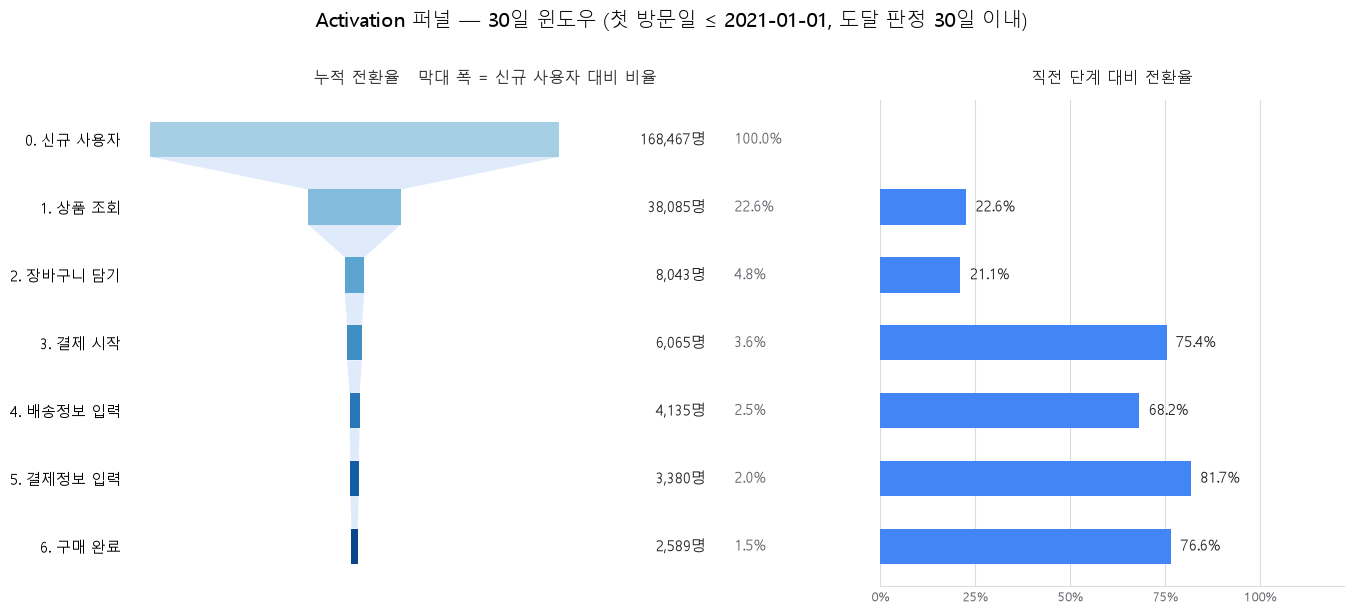

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

labels = funnel_win_df['단계'].tolist()
users  = funnel_win_df['사용자수'].to_numpy()
cum    = funnel_win_df['신규대비(%)'].to_numpy()
step   = funnel_win_df['직전대비(%)'].to_numpy()
n      = len(labels)

width  = users / users[0]          # 막대 폭 = 누적 전환율
colors = plt.cm.Blues(np.linspace(0.35, 0.92, n))
BAR_H  = 0.52

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.4), sharey=True,
                               gridspec_kw={'width_ratios': [1.55, 1], 'wspace': 0.06})

# 단계 사이 사다리꼴 연결부 → 퍼널 형태
for i in range(n - 1):
    w0, w1 = width[i] / 2, width[i + 1] / 2
    ax1.fill([-w0, w0, w1, -w1],
             [i + BAR_H / 2, i + BAR_H / 2, i + 1 - BAR_H / 2, i + 1 - BAR_H / 2],
             color='#C6DAF6', alpha=0.55, linewidth=0)

ax1.barh(range(n), width, left=-width / 2, height=BAR_H, color=colors)
for i in range(n):
    ax1.text(0.86, i, f'{users[i]:,}명', va='center', ha='right', fontsize=10.5, color='#202124')
    ax1.text(0.93, i, f'{cum[i]:.1f}%',  va='center', ha='left',  fontsize=10.5, color='#5F6368')
ax1.set_xlim(-0.56, 1.20)
ax1.set_xticks([])
ax1.set_yticks(range(n))
ax1.set_yticklabels(labels, fontsize=11)
ax1.invert_yaxis()
ax1.set_title('누적 전환율   막대 폭 = 신규 사용자 대비 비율', fontsize=11.5, pad=12, color='#202124')
for s in ax1.spines.values():
    s.set_visible(False)
ax1.tick_params(length=0)

ax2.barh(range(1, n), step[1:], height=BAR_H, color='#4285F4')
for i in range(1, n):
    ax2.text(step[i] + 2.5, i, f'{step[i]:.1f}%', va='center', ha='left', fontsize=10.5, color='#202124')
ax2.set_xlim(0, 122)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9.5, color='#5F6368')
ax2.set_title('직전 단계 대비 전환율', fontsize=11.5, pad=12, color='#202124')
ax2.xaxis.grid(True, color='#DADCE0', linewidth=0.8)
ax2.set_axisbelow(True)
for s in ('top', 'right', 'left'):
    ax2.spines[s].set_visible(False)
ax2.spines['bottom'].set_color('#DADCE0')
ax2.tick_params(length=0)

fig.suptitle('Activation 퍼널 — 30일 윈도우 (첫 방문일 ≤ 2021-01-01, 도달 판정 30일 이내)',
             fontsize=14.5, y=0.98)
fig.subplots_adjust(top=0.84, bottom=0.08, left=0.11, right=0.98)

plt.savefig('activation_funnel_30d.png', dpi=150, bbox_inches='tight')
plt.show()